In [1]:
import torch
import rasterio
import matplotlib.pyplot as plt
from utils.datasets_chloe import DataAugmentationForMultiMAE

# --------------------------
# Loader 함수 (dataset_folder_chloe.py와 동일 로직)
# --------------------------
def rasterio_loader(path: str) -> torch.Tensor:
    if "S1" in path:
        with rasterio.open(path) as src:
            img = src.read(out_dtype='float32')
            img[img == -9999] = 0
        return torch.from_numpy(img).float()

    elif "S2" in path:
        with rasterio.open(path) as src:
            img = src.read(out_dtype='float32')
            img[img == -9999] = 0
            img = img / 10000.0
        return torch.from_numpy(img).float()

    else:  # CDL
        with rasterio.open(path) as src:
            img = src.read(1, out_dtype='int32')
        img = torch.from_numpy(img).long()
        # Corn=1 유지, Soybean=5 → 2, 나머지=0
        img = torch.where(img == 1, torch.tensor(1, device=img.device), img)
        img = torch.where(img == 5, torch.tensor(2, device=img.device), img)
        img = torch.where((img != 1) & (img != 2), torch.tensor(0, device=img.device), img)
        return img.unsqueeze(0)  # [1,H,W]

In [4]:
# --------------------------
# 실제 경로
# --------------------------
s1_path = "/work/mech-ai-scratch/bgekim/project/imputation/IA_dataset/30m/Patches/S1/patch_0_336/2020-04-26_IA.tif"
s2_path = "/work/mech-ai-scratch/bgekim/project/imputation/IA_dataset/30m/Patches/S2/patch_0_336/2020-04-26_IA.tif"
cdl_path = "/work/mech-ai-scratch/bgekim/project/imputation/IA_dataset/30m/Patches/CDL/patch_0_336/reprojected_IA.tif"

Shapes: {'s1': torch.Size([2, 224, 224]), 's2': torch.Size([12, 224, 224]), 'cdl': torch.Size([1, 224, 224])}


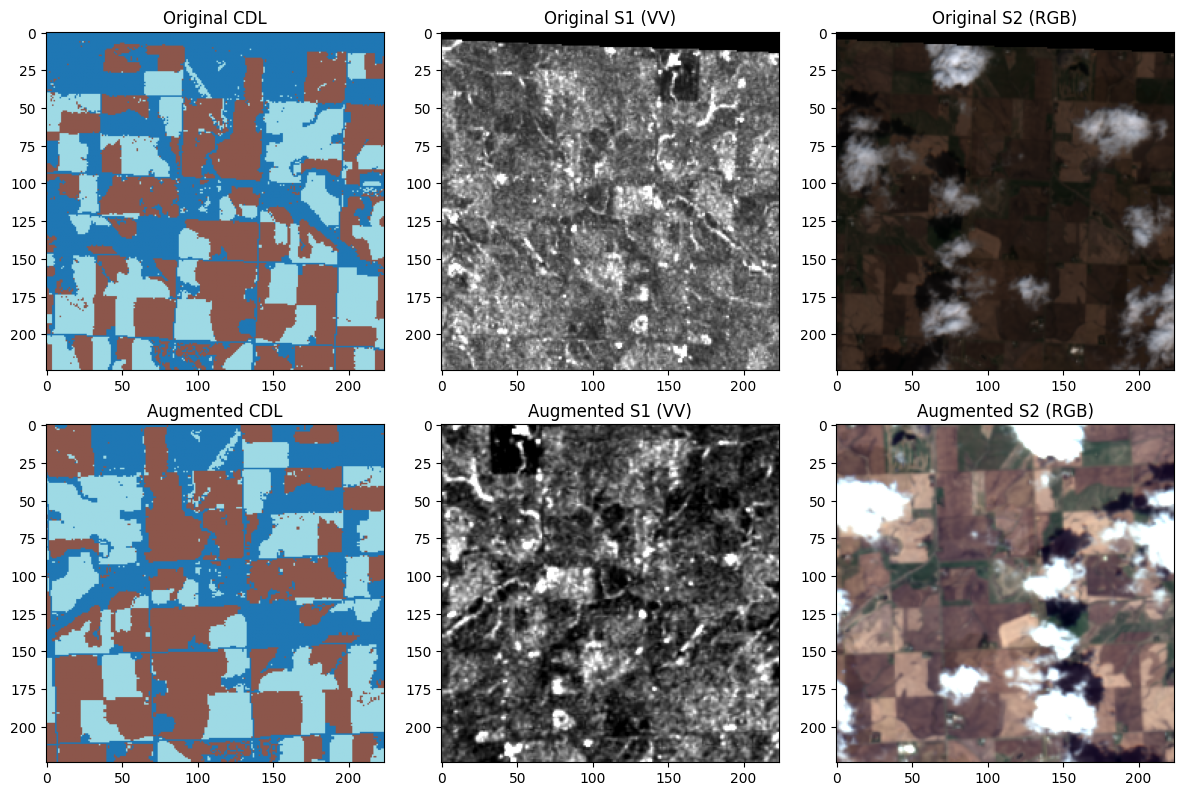

In [9]:
import numpy as np

# --------------------------
# 데이터 로드
# --------------------------
sample = {
    "s1": rasterio_loader(s1_path),
    "s2": rasterio_loader(s2_path),
    "cdl": rasterio_loader(cdl_path),
}

print("Shapes:", {k: v.shape for k,v in sample.items()})  # 확인용

# --------------------------
# Augmentation 객체
# --------------------------
class DummyArgs:
    input_size = 224
    hflip = 0.5   # 50% 확률 flip
    all_domains = ["s1", "s2", "cdl"]

args = DummyArgs()
aug = DataAugmentationForMultiMAE(args)

# --------------------------
# Augmentation 적용
# --------------------------
aug_sample = aug(sample)


def normalize_to_01(img):
    img = img.numpy()
    vmin, vmax = np.percentile(img, (2, 98))  # 극단값 잘라내기 (옵션)
    img = np.clip((img - vmin) / (vmax - vmin + 1e-6), 0, 1)
    return img

# --------------------------
# 시각화
# --------------------------
fig, axs = plt.subplots(2, 3, figsize=(12, 8))

# CDL
axs[0,0].imshow(sample["cdl"][0], cmap="tab20")
axs[0,0].set_title("Original CDL")
axs[1,0].imshow(aug_sample["cdl"][0], cmap="tab20")
axs[1,0].set_title("Augmented CDL")

# S1 (VV 밴드만)
# axs[0,1].imshow(sample["s1"][0], cmap="gray")
# axs[0,1].set_title("Original S1 (VV)")
# axs[1,1].imshow(aug_sample["s1"][0], cmap="gray")
# axs[1,1].set_title("Augmented S1 (VV)")
# S1 (VV 밴드만, [0])
orig_s1 = normalize_to_01(sample["s1"][0])
aug_s1 = normalize_to_01(aug_sample["s1"][0])

axs[0,1].imshow(orig_s1, cmap="gray")
axs[0,1].set_title("Original S1 (VV)")
axs[1,1].imshow(aug_s1, cmap="gray")
axs[1,1].set_title("Augmented S1 (VV)")

# S2 (RGB만)
rgb_idx = [3,2,1]  # Sentinel-2 R,G,B
orig_rgb = sample["s2"][rgb_idx].permute(1,2,0).numpy()
aug_rgb = aug_sample["s2"][rgb_idx].permute(1,2,0).numpy()

axs[0,2].imshow((orig_rgb - orig_rgb.min())/(orig_rgb.max()-orig_rgb.min()))
axs[0,2].set_title("Original S2 (RGB)")
axs[1,2].imshow((aug_rgb - aug_rgb.min())/(aug_rgb.max()-aug_rgb.min()))
axs[1,2].set_title("Augmented S2 (RGB)")

plt.tight_layout()
plt.show()


In [10]:
import os

s2_txt = "/work/mech-ai-scratch/bgekim/project/imputation/MultiMAE_NEW/MultiMAE/valid_list/nova/30m/pair_S2.txt"
cdl_txt = "/work/mech-ai-scratch/bgekim/project/imputation/MultiMAE_NEW/MultiMAE/valid_list/nova/30m/pair_CDL.txt"

lines = []
with open(s2_txt, "r") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        # patch_x_y 부분만 추출
        patch_dir = os.path.dirname(line)  # .../patch_0_336
        cdl_path = os.path.join(patch_dir, "reprojected_IA.tif")
        lines.append(cdl_path)

# 저장
with open(cdl_txt, "w") as f:
    f.write("\n".join(lines))

print(f"✅ CDL txt 생성 완료: {cdl_txt}, 총 {len(lines)} 라인")


✅ CDL txt 생성 완료: /work/mech-ai-scratch/bgekim/project/imputation/MultiMAE_NEW/MultiMAE/valid_list/nova/30m/pair_CDL.txt, 총 118059 라인


In [12]:
import os

cdl_txt_in = "/work/mech-ai-scratch/bgekim/project/imputation/MultiMAE_NEW/MultiMAE/valid_list/nova/30m/pair_CDL.txt"
cdl_txt_out = "/work/mech-ai-scratch/bgekim/project/imputation/MultiMAE_NEW/MultiMAE/valid_list/nova/30m/pair_CDL_fixed.txt"

lines = []
with open(cdl_txt_in, "r") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        # 문자열 교체 (S2 → cdl)
        fixed = line.replace("/Patches/S2/", "/Patches/CDL/")
        lines.append(fixed)

# 저장
with open(cdl_txt_out, "w") as f:
    f.write("\n".join(lines))

print(f"✅ S2 → cdl 경로 변환 완료: {cdl_txt_out}, 총 {len(lines)} 라인")


✅ S2 → cdl 경로 변환 완료: /work/mech-ai-scratch/bgekim/project/imputation/MultiMAE_NEW/MultiMAE/valid_list/nova/30m/pair_CDL_fixed.txt, 총 118059 라인
